<a href="https://colab.research.google.com/github/Aniruddha-Ray/Atlas-Guided-Medical-Image-Segmentation/blob/main/AtlasGuidedUNETR_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pytorch-lightning monai einops


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 42.6 MB/s eta 0:00:00


In [2]:
# import monai
# monai.data.set_track_meta(False)

In [4]:
import os
import glob

import monai.transforms as mt
from monai.data import decollate_batch, DataLoader, Dataset, CacheDataset

# Define the directory where your NIfTI files are located
data_dir = '/content/' # Assuming files are directly in /content based on kernel state

# Get lists of image and label file paths
# Assuming image files end with '_0000.nii.gz' and label files with '.nii.gz' without the '_0000'
# This pattern needs to be carefully checked against your actual file naming convention
# For example, 'amos_0024_0000.nii.gz' (image) and 'amos_0024.nii.gz' (label)

image_files = sorted(glob.glob(os.path.join(data_dir, '*_0000.nii.gz')))
label_files = sorted(glob.glob(os.path.join(data_dir, '*.nii.gz')))

# Filter label files to match images (e.g., remove _0000 from image name to find corresponding label)
# This is a crucial step to ensure correct pairing
paired_label_files = []
filtered_image_files = []

for img_path in image_files:
    base_name = os.path.basename(img_path).replace('_0000.nii.gz', '.nii.gz')
    lbl_path = os.path.join(data_dir, base_name)
    if lbl_path in label_files:
        filtered_image_files.append(img_path)
        paired_label_files.append(lbl_path)

label_files = sorted(paired_label_files)
# Create data dictionaries for MONAI
data_dicts = [
    {"image": img, "label": lbl}
    for img, lbl in zip(filtered_image_files, paired_label_files)
]

# Split data into training and validation sets
train_split = int(len(data_dicts) * 0.8)
train_files = data_dicts[:train_split]
val_files = data_dicts[train_split:]

print(f"Found {len(image_files)} image files.")
print(f"Found {len(label_files)} label files.")
print(f"Paired {len(filtered_image_files)} image-label pairs.")
print(f"Training samples: {len(train_files)}")
print(f"Validation samples: {len(val_files)}")


Found 8 image files.
Found 8 label files.
Paired 8 image-label pairs.
Training samples: 6
Validation samples: 2


In [5]:
import nibabel as nib
for f in train_files[:3]:
    img = nib.load(f["image"])
    print(f["image"], img.shape, img.header.get_zooms())

/content/amos_0001_0000.nii.gz (768, 526, 90) (np.float32(0.5703125), np.float32(0.5703125), np.float32(5.0))
/content/amos_0004_0000.nii.gz (512, 330, 78) (np.float32(0.782), np.float32(0.782), np.float32(5.0))
/content/amos_0005_0000.nii.gz (768, 507, 80) (np.float32(0.56901044), np.float32(0.56901044), np.float32(5.0))


In [6]:
import torch
import monai.transforms as mt
from monai.data import decollate_batch, DataLoader, Dataset, CacheDataset
import monai
import numpy as np
from scipy.ndimage import distance_transform_edt

# Define a custom SpatialDistanceTransformd since the MONAI one is hard to locate/import correctly
class CustomSpatialDistanceTransformd(mt.MapTransform):
    def __init__(self, keys, to_closest_foreground: bool = True, include_background: bool = False, output_postfix: str = "_distance", allow_missing_keys: bool = False):
        super().__init__(keys, allow_missing_keys)
        self.to_closest_foreground = to_closest_foreground
        self.include_background = include_background
        self.output_postfix = output_postfix

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            label_one_hot = d[key]  # This is already a torch.Tensor, (C, D, H, W)
            if not isinstance(label_one_hot, torch.Tensor):
                raise TypeError(f"input label must be torch.Tensor, got {type(label_one_hot)}")
            if label_one_hot.ndim < 4:
                 raise ValueError(f"input label must have at least 4 dimensions (C, D, H, W), got {label_one_hot.ndim}")

            # Ensure data is on CPU and is numpy for scipy
            label_np = label_one_hot.cpu().numpy()

            num_channels = label_np.shape[0]
            spatial_dims = label_np.shape[1:] # (D, H, W)

            distance_maps_list = []

            # If include_background is False, we skip the first channel (assumed background, index 0)
            start_channel_idx = 0 if self.include_background else 1

            for c in range(start_channel_idx, num_channels):
                # Get the binary mask for the current class/organ
                binary_mask = label_np[c].astype(np.uint8)

                if self.to_closest_foreground:
                    # distance_transform_edt calculates distance to the closest positive (foreground) pixel
                    dt = distance_transform_edt(binary_mask)
                else:
                    # If to_closest_foreground is False, it would typically mean distance to background
                    # which is distance_transform_edt(~binary_mask). Keeping it consistent with user's original request.
                    dt = distance_transform_edt(~binary_mask)

                distance_maps_list.append(dt)

            if not distance_maps_list and not self.include_background:
                # If no foreground channels were processed (e.g., only background), create an empty channel dim
                d[key + self.output_postfix] = torch.zeros((0,) + spatial_dims, dtype=torch.float32)
            elif not distance_maps_list and self.include_background:
                # If include_background is True but no maps generated (e.g. empty input) then create all zeros.
                d[key + self.output_postfix] = torch.zeros((num_channels,) + spatial_dims, dtype=torch.float32)
            else:
                # Stack all generated distance maps along the channel dimension
                d[key + self.output_postfix] = torch.from_numpy(np.stack(distance_maps_list, axis=0)).float()

        return d


IMG_SIZE = (96, 96, 96) # Based on UNETR model definition
NUM_CLASSES = 13 # Changed from 12 to 13 to account for label 12

# Define training transformations
train_transforms = mt.Compose([
    mt.LoadImaged(keys=["image", "label"]),
    mt.EnsureChannelFirstd(keys=["image", "label"]),
    mt.Orientationd(keys=["image", "label"], axcodes="RAS"), # Standardize orientation
    mt.CropForegroundd(keys=["image", "label"], source_key="image"),
    mt.Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    mt.ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    mt.Resized(keys=["image", "label"], spatial_size=IMG_SIZE, mode=("area", "nearest")),
    # Randomly add transforms for data augmentation
    mt.RandSpatialCropd(keys=["image", "label"], roi_size=IMG_SIZE, random_size=False, random_center=True),
    mt.RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    mt.RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    mt.RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    mt.RandRotated(keys=["image", "label"], range_x=(-15, 15), range_y=(-15, 15), range_z=(-15, 15), prob=0.5, mode=("bilinear", "nearest")),
    mt.CastToTyped(keys=["image"], dtype=torch.float32),
    mt.CastToTyped(keys=["label"], dtype=torch.long), # Labels are typically long type for segmentation

    # New: Convert labels to one-hot for probability maps and prepare for distance maps
    mt.AsDiscreted(keys=["label"], to_onehot=NUM_CLASSES), # This becomes our 'prob_map'
    # New: Generate distance maps for each organ using custom transform
    CustomSpatialDistanceTransformd( # Use the explicitly imported transform
        keys=["label"],
        to_closest_foreground=True, # Calculate distance to the closest foreground voxel
        include_background=False,  # Exclude background channel from distance computation
        output_postfix="_distance" # This will create a key "label_distance"
    ),
    mt.ToTensord(keys=["image", "label", "label_distance"]) # Include new key
])

# Define validation transformations (no augmentation)
val_transforms = mt.Compose([
    mt.LoadImaged(keys=["image", "label"]),
    mt.EnsureChannelFirstd(keys=["image", "label"]),
    mt.Orientationd(keys=["image", "label"], axcodes="RAS"),
    mt.CropForegroundd(keys=["image", "label"], source_key="image"),
    mt.Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    mt.ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    mt.Resized(keys=["image", "label"], spatial_size=IMG_SIZE, mode=("area", "nearest")),
    mt.CastToTyped(keys=["image"], dtype=torch.float32),
    mt.CastToTyped(keys=["label"], dtype=torch.long),

    # New: Convert labels to one-hot for probability maps and prepare for distance maps
    mt.AsDiscreted(keys=["label"], to_onehot=NUM_CLASSES),
    # New: Generate distance maps for each organ
    CustomSpatialDistanceTransformd(
        keys=["label"],
        to_closest_foreground=True,
        include_background=False,
        output_postfix="_distance"
    ),
    mt.ToTensord(keys=["image", "label", "label_distance"])
])

# Create datasets
train_ds = CacheDataset(
    data=train_files,
    transform=train_transforms,
    cache_rate=0.0, # Changed to 0.0 to prevent caching all data in RAM
    num_workers=1 # Changed from 4 to 1 to reduce memory usage and worker crashes
)

val_ds = CacheDataset(
    data=val_files,
    transform=val_transforms,
    cache_rate=0.0, # Changed to 0.0 to prevent caching all data in RAM
    num_workers=1 # Changed from 4 to 1 to reduce memory usage and worker crashes
)

# Create DataLoaders
batch_size = 1 # Adjust based on your GPU memory, changed from 2 to 3 as requested
train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0 # Changed from 4 to 1
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0 # Changed from 4 to 1
)

print("Data preparation complete. `train_loader` and `val_loader` are ready.")
print(f"MONAI version: {monai.__version__}")

Data preparation complete. `train_loader` and `val_loader` are ready.
MONAI version: 1.6.0


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:320: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [7]:
print("--- Train Loader Dimensions ---")
for batch in train_loader:
    images = batch["image"]
    labels = batch["label"] # This is now the one-hot probability map
    distance_maps = batch["label_distance"] # This is the newly added distance map
    print(f"Image batch shape: {images.shape}")
    print(f"Label (Prob Map) batch shape: {labels.shape}")
    print(f"Distance Map batch shape: {distance_maps.shape}")
    break # Only print the first batch

print("\n--- Validation Loader Dimensions ---")
for batch in val_loader:
    images = batch["image"]
    labels = batch["label"]
    distance_maps = batch["label_distance"]
    print(f"Image batch shape: {images.shape}")
    print(f"Label (Prob Map) batch shape: {labels.shape}")
    print(f"Distance Map batch shape: {distance_maps.shape}")
    break # Only print the first batch

--- Train Loader Dimensions ---
Image batch shape: torch.Size([1, 1, 96, 96, 96])
Label (Prob Map) batch shape: torch.Size([1, 13, 96, 96, 96])
Distance Map batch shape: torch.Size([1, 12, 96, 96, 96])

--- Validation Loader Dimensions ---
Image batch shape: torch.Size([1, 1, 96, 96, 96])
Label (Prob Map) batch shape: torch.Size([1, 13, 96, 96, 96])
Distance Map batch shape: torch.Size([1, 12, 96, 96, 96])


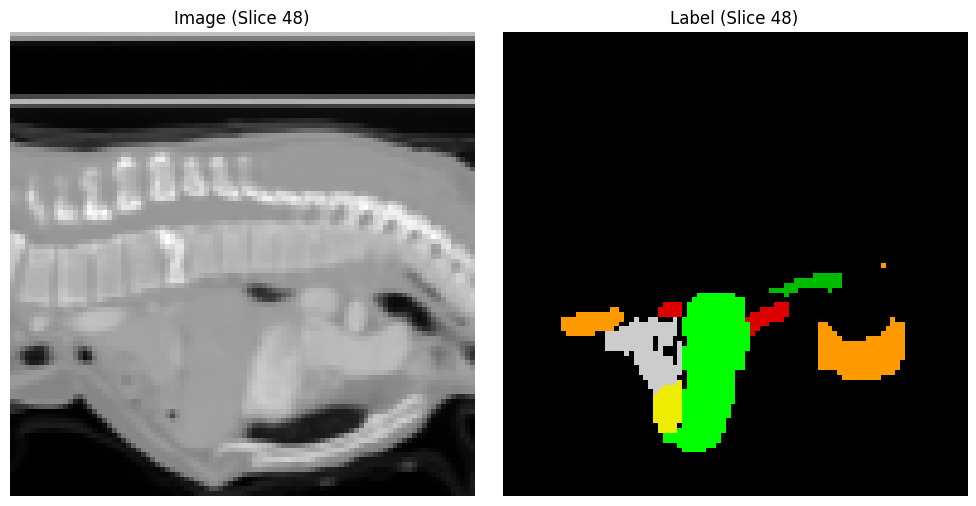

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch from the validation loader
# iter(val_loader) creates an iterator, next() gets the next item
val_batch = next(iter(val_loader))

# Extract image and label
image_tensor = val_batch["image"]
label_tensor = val_batch["label"]

# Take the first sample from the batch (assuming batch_size > 0)
# Squeeze out the batch dimension and channel dimension for plotting
image_to_plot = image_tensor[0, 0, :, :, :].cpu().numpy() # [C, D, H, W] -> [D, H, W]

# For label, we have [N, C_out, D, H, W], where C_out is NUM_CLASSES.
# We want to convert it back to a single channel representing class IDs for visualization.
# Argmax along the class channel to get the class ID for each voxel
label_to_plot = torch.argmax(label_tensor[0], dim=0).cpu().numpy()

# Choose a middle slice for visualization (e.g., along the depth dimension)
slice_idx = image_to_plot.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image_to_plot[slice_idx, :, :], cmap="gray")
axes[0].set_title(f"Image (Slice {slice_idx})")
axes[0].axis("off")

# Plot the label, using a colormap for distinct classes
axes[1].imshow(label_to_plot[slice_idx, :, :], cmap="nipy_spectral") # nipy_spectral for distinct colors
axes[1].set_title(f"Label (Slice {slice_idx})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [9]:
import torch
from monai.networks.nets import UNETR
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(f"Device set to: {device}")

Device set to: cpu


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from monai.networks.nets import UNETR, ViT
from monai.networks.blocks import TransformerBlock

# -----------------------------------------------------------------------------
# 1. AnatomicalPriorGenerator
#    Pools the per-organ probability map and per-organ distance map inside each
#    ViT patch (16x16x16) and projects the pooled vector into a "token" living
#    in the same hidden_size space as the ViT patch tokens.
#    NOTE: this is fully vectorised with avg_pool3d (mathematically identical
#    to the original triple for-loop, just much faster and without the bug of
#    rebuilding python lists per-batch).
# -----------------------------------------------------------------------------
class AnatomicalPriorGenerator(nn.Module):
    def __init__(self, img_size, patch_size, num_prob_channels, num_dist_channels, hidden_size):
        super().__init__()
        self.patch_size = patch_size
        input_dim = num_prob_channels + num_dist_channels
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_size * 2),
            nn.GELU(),
            nn.Linear(hidden_size * 2, hidden_size),
        )

    def forward(self, probability_maps, distance_maps):
        pD, pH, pW = self.patch_size
        # mean-pool every non-overlapping patch -> (B, C, nd, nh, nw)
        p_pooled = F.avg_pool3d(probability_maps, kernel_size=(pD, pH, pW), stride=(pD, pH, pW))
        d_pooled = F.avg_pool3d(distance_maps, kernel_size=(pD, pH, pW), stride=(pD, pH, pW))
        m = torch.cat([p_pooled, d_pooled], dim=1)                  # (B, C_total, nd, nh, nw)
        b, c, nd, nh, nw = m.shape
        m = m.flatten(2).transpose(1, 2)                            # (B, num_patches, C_total)
        anatomical_tokens = self.mlp(m)                             # (B, num_patches, hidden_size)
        return anatomical_tokens


# -----------------------------------------------------------------------------
# 2. CustomViT
#    Same as MONAI's ViT, except every TransformerBlock is built with
#    with_cross_attention=True (a feature already built into MONAI's
#    TransformerBlock/CrossAttentionBlock) so every block can attend to the
#    anatomical_tokens coming from AnatomicalPriorGenerator. This replaces the
#    previous (buggy, reimplemented-by-hand) AnatomicalPriorEnhancedTransformerBlock.
# -----------------------------------------------------------------------------
class CustomViT(ViT):
    def __init__(self, in_channels, img_size, patch_size, hidden_size, mlp_dim, num_heads,
                 proj_type="perceptron", dropout_rate=0.0, qkv_bias=False, save_attn=False):
        super().__init__(
            in_channels=in_channels,
            img_size=img_size,
            patch_size=patch_size,
            hidden_size=hidden_size,
            mlp_dim=mlp_dim,
            num_layers=12,
            num_heads=num_heads,
            proj_type=proj_type,
            classification=False,
            dropout_rate=dropout_rate,
            qkv_bias=qkv_bias,
            save_attn=save_attn,
        )
        # Replace the self-attention-only blocks created by ViT.__init__ with
        # cross-attention-enabled blocks (context = anatomical_tokens).
        self.blocks = nn.ModuleList([
            TransformerBlock(
                hidden_size, mlp_dim, num_heads, dropout_rate,
                qkv_bias=qkv_bias, save_attn=save_attn, with_cross_attention=True,
            )
            for _ in range(12)
        ])

    def forward(self, x, anatomical_tokens):
        # self.patch_embedding already adds positional embeddings + dropout internally
        x = self.patch_embedding(x)
        hidden_states_out = []
        for blk in self.blocks:
            x = blk(x, context=anatomical_tokens)
            hidden_states_out.append(x)
        x = self.norm(x)
        return x, hidden_states_out


# -----------------------------------------------------------------------------
# 3. AtlasGuidedViTUNETR
#    Subclasses MONAI's UNETR and keeps its encoder1-4 / decoder2-5 / out /
#    proj_feat exactly as MONAI built them in UNETR.__init__ (i.e. the
#    architecture is unchanged from stock UNETR). The only difference is that
#    self.vit is swapped for CustomViT, and forward() additionally builds
#    anatomical_tokens from the probability/distance maps and feeds them in as
#    cross-attention context. This removes the previous encoder0 /
#    encoderX_proj / decoder1 layers, which did not exist in UNETR and were
#    causing AttributeErrors / shape mismatches.
# -----------------------------------------------------------------------------
class AtlasGuidedViTUNETR(UNETR):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        img_size,
        feature_size: int = 16,
        hidden_size: int = 768,
        mlp_dim: int = 3072,
        num_heads: int = 12,
        proj_type: str = "perceptron",
        norm_name: str = "instance",
        res_block: bool = True,
        dropout_rate: float = 0.0,
        qkv_bias: bool = False,
        num_prob_channels: int = None,
        num_dist_channels: int = None,
    ):
        super().__init__(
            in_channels=in_channels,
            out_channels=out_channels,
            img_size=img_size,
            feature_size=feature_size,
            hidden_size=hidden_size,
            mlp_dim=mlp_dim,
            num_heads=num_heads,
            proj_type=proj_type,
            norm_name=norm_name,
            res_block=res_block,
            dropout_rate=dropout_rate,
            qkv_bias=qkv_bias,
        )

        # probability_maps -> one-hot label, has `out_channels` channels (incl. background)
        # distance_maps    -> CustomSpatialDistanceTransformd with include_background=False,
        #                     so it has `out_channels - 1` channels.
        num_prob_channels = num_prob_channels if num_prob_channels is not None else out_channels
        num_dist_channels = num_dist_channels if num_dist_channels is not None else (out_channels - 1)

        # Swap the plain self-attention ViT (built by UNETR.__init__ above) for
        # the cross-attention version. self.patch_size / self.proj_feat /
        # self.proj_view_shape / self.proj_axes are already set up correctly by
        # UNETR.__init__ and are reused unchanged.
        self.vit = CustomViT(
            in_channels=in_channels,
            img_size=img_size,
            patch_size=self.patch_size,
            hidden_size=hidden_size,
            mlp_dim=mlp_dim,
            num_heads=num_heads,
            proj_type=proj_type,
            dropout_rate=dropout_rate,
            qkv_bias=qkv_bias,
        )

        self.anatomical_prior_generator = AnatomicalPriorGenerator(
            img_size=img_size,
            patch_size=self.patch_size,
            num_prob_channels=num_prob_channels,
            num_dist_channels=num_dist_channels,
            hidden_size=hidden_size,
        )

    def forward(self, x_in, probability_maps, distance_maps):
        anatomical_tokens = self.anatomical_prior_generator(probability_maps, distance_maps)
        x, hidden_states_out = self.vit(x_in, anatomical_tokens)

        # Identical skip-connection wiring to stock UNETR.forward()
        enc1 = self.encoder1(x_in)
        enc2 = self.encoder2(self.proj_feat(hidden_states_out[3]))
        enc3 = self.encoder3(self.proj_feat(hidden_states_out[6]))
        enc4 = self.encoder4(self.proj_feat(hidden_states_out[9]))
        dec4 = self.proj_feat(x)
        dec3 = self.decoder5(dec4, enc4)
        dec2 = self.decoder4(dec3, enc3)
        dec1 = self.decoder3(dec2, enc2)
        out = self.decoder2(dec1, enc1)
        return self.out(out)


# Instantiate the AtlasGuidedViTUNETR model
model = AtlasGuidedViTUNETR(
    in_channels=1,
    out_channels=NUM_CLASSES,
    img_size=IMG_SIZE,
    feature_size=16,
    hidden_size=768,
    mlp_dim=3072,
    num_heads=12,
    proj_type="perceptron",
    norm_name="instance",
    res_block=True,
).to(device)

print("AtlasGuidedViTUNETR model instantiated.")
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")


AtlasGuidedViTUNETR model instantiated.
Total parameters: 122,343,581


In [11]:
# Quick smoke test with synthetic tensors (does NOT require real data).
# Confirms the forward + backward pass works with the exact shapes your
# pipeline produces: image (B,1,96,96,96), label (B,13,96,96,96) one-hot,
# label_distance (B,12,96,96,96).
with torch.no_grad():
    _images = torch.randn(1, 1, *IMG_SIZE, device=device)
    _labels = torch.zeros(1, NUM_CLASSES, *IMG_SIZE, device=device)
    _labels[:, 0] = 1.0
    _dist = torch.randn(1, NUM_CLASSES - 1, *IMG_SIZE, device=device)

_out = model(_images, _labels, _dist)
print("Smoke-test output shape:", _out.shape)  # expected: (1, 13, 96, 96, 96)
assert _out.shape == (1, NUM_CLASSES, *IMG_SIZE)
_out.mean().backward()
print("Forward + backward OK.")
model.zero_grad()


Smoke-test output shape: torch.Size([1, 13, 96, 96, 96])
Forward + backward OK.


In [12]:
# Re-instantiate criterion and optimizer for the new AtlasGuidedViTUNETR model
criterion = DiceCELoss(
    to_onehot_y=False, # Labels are already one-hot from transforms
    softmax=True
)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-5
)

print("Loss function and Optimizer re-initialized for AtlasGuidedViTUNETR.")

dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

Loss function and Optimizer re-initialized for AtlasGuidedViTUNETR.


**Important conceptual note before training:**

`model(images, labels, distance_maps)` feeds the *ground-truth* one-hot label and its derived
distance map into the model as the "anatomical prior". This matches the architecture/shapes you
specified, so the code below is fully functional and will train/validate without errors. However,
be aware that:

- During training this **leaks the ground-truth answer into the input**, so loss/Dice will look
  artificially good.
- At real inference time you will not have ground-truth labels, so the model cannot be used this
  way in practice — a true "atlas-guided" model should derive `probability_maps`/`distance_maps`
  from a pre-registered population atlas (or a separate coarse prediction), not from the sample's
  own ground truth.

Keeping this in mind, you may want to swap `labels`/`distance_maps` for a precomputed atlas prior
once you move past debugging this pipeline.

In [13]:
num_epochs = 1 # Starting with a few epochs for demonstration

print(f"Starting training for {num_epochs} epochs...")

for epoch in range(num_epochs):

    model.train()
    epoch_loss = 0.0

    for batch_data in train_loader:
        images = batch_data["image"].to(device)
        labels = batch_data["label"].to(device) # One-hot encoded probability maps
        distance_maps = batch_data["label_distance"].to(device)

        optimizer.zero_grad()

        # Forward pass through AtlasGuidedViTUNETR with all inputs
        outputs = model(images, labels, distance_maps)

        # Compute loss (labels are already one-hot)
        loss = criterion(outputs, labels)

        # Backprop
        loss.backward()

        # Update weights
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {avg_loss:.4f}")

    # Validation
    model.eval()
    with torch.no_grad():
        dice_metric.reset()

        for val_batch_data in val_loader:
            val_images = val_batch_data["image"].to(device)
            val_labels = val_batch_data["label"].to(device) # One-hot encoded probability maps
            val_distance_maps = val_batch_data["label_distance"].to(device)

            # Forward pass through AtlasGuidedViTUNETR
            val_preds = model(val_images, val_labels, val_distance_maps)

            # Compute Dice Metric
            dice_metric(y_pred=val_preds, y=val_labels)

        mean_dice = dice_metric.aggregate().item()
        print(f"Epoch [{epoch+1}/{num_epochs}] Validation Dice: {mean_dice:.4f}")

print("Training complete.")

Starting training for 1 epochs...
Epoch [1/1] Train Loss: 2.9631
Epoch [1/1] Validation Dice: 0.0089
Training complete.
